In [1]:
import convolutions
import skimage.io as skio
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
import cv2
from skimage.transform import resize
from align_image_code import align_images
%matplotlib inline

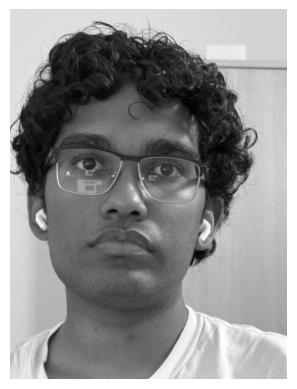

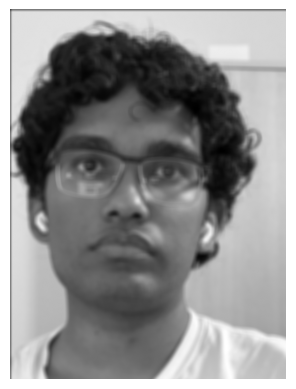

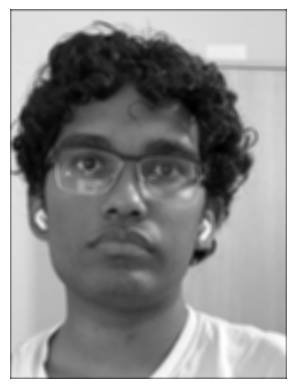

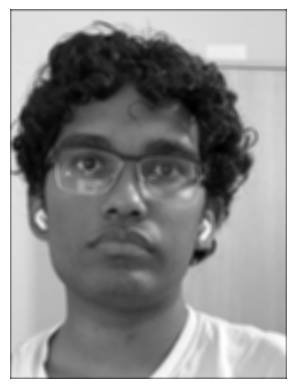

In [2]:
me_img = skio.imread("media/me_far.jpeg", as_gray = True)
me_img = np.rot90(me_img, k=-1)
h, w = me_img.shape[:2]
me_img = resize(me_img, (h // 6, w // 6), anti_aliasing=True)

box = np.ones((9,9)) / 81

conv4 = convolutions.convolution4(me_img, box, mode = "same")
conv2 = convolutions.convolution(me_img, box, mode = "same")
sci_py_conv = convolve2d(me_img, box, mode="same")


plt.imshow(me_img, cmap="gray"); plt.axis("off"); plt.show()
plt.imshow(conv4, cmap="gray"); plt.axis("off"); plt.show()
plt.imshow(conv2, cmap="gray"); plt.axis("off"); plt.show()
plt.imshow(sci_py_conv, cmap="gray"); plt.axis("off"); plt.show()

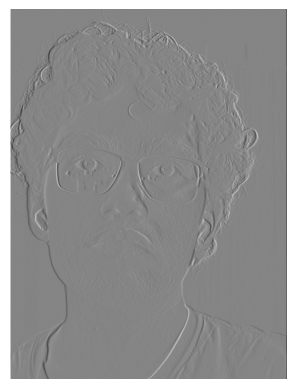

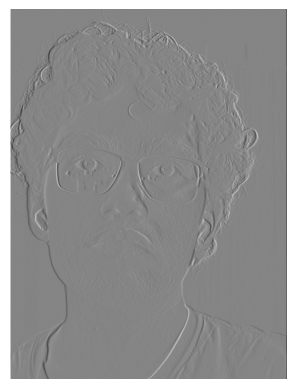

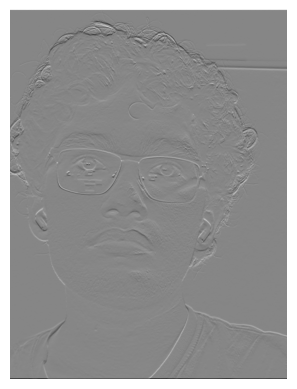

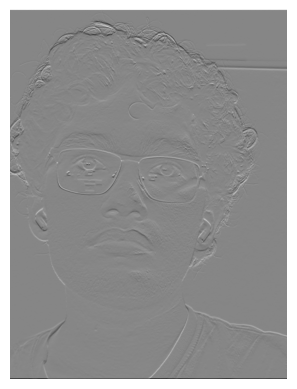

In [3]:
Dx = np.array([[1, 0, -1]])
Dy = np.array([[1],[0],[-1]])
conv2x = convolutions.convolution(me_img, Dx, mode = "same")
sci_py_convx = convolve2d(me_img, Dx, mode="same")
conv2y = convolutions.convolution(me_img, Dy, mode = "same")
sci_py_convy = convolve2d(me_img, Dy, mode="same")

plt.imshow(conv2x, cmap="gray"); plt.axis("off"); plt.show()
plt.imshow(sci_py_convx, cmap="gray"); plt.axis("off"); plt.show()
plt.imshow(conv2y, cmap="gray"); plt.axis("off"); plt.show()
plt.imshow(sci_py_convy, cmap="gray"); plt.axis("off"); plt.show()

Text(0.5, 1.0, 'Dy')

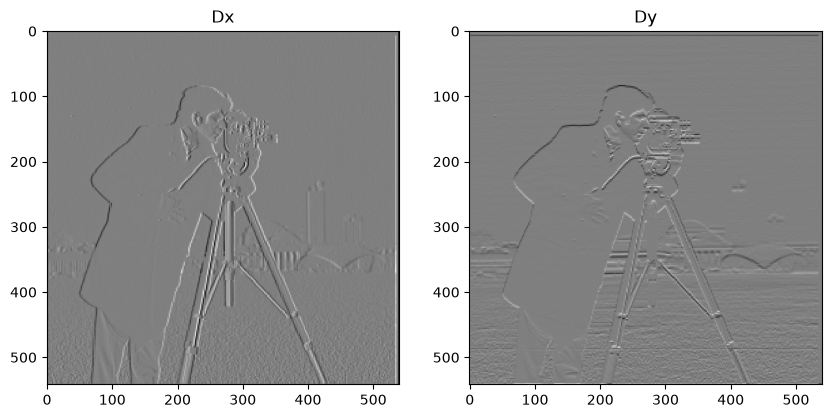

In [4]:
cameraman_img = skio.imread("media/cameraman.png", as_gray=True)
conv2x = convolutions.convolution(cameraman_img, Dx, mode = "same")
conv2y = convolutions.convolution(cameraman_img, Dy, mode = "same")
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(conv2x, cmap="gray"); ax[0].set_title("Dx")
ax[1].imshow(conv2y, cmap="gray"); ax[1].set_title("Dy")

(np.float64(-0.5), np.float64(539.5), np.float64(541.5), np.float64(-0.5))

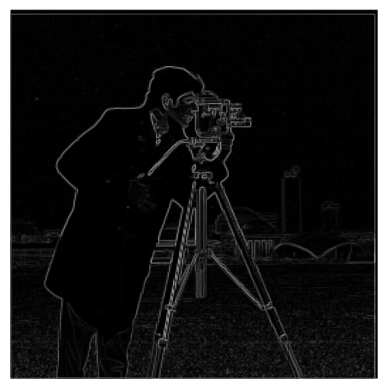

In [5]:
#Gradient magnitude!
cam_gradmag = np.sqrt(conv2x**2 + conv2y**2)
plt.imshow(cam_gradmag, cmap="gray"); plt.axis("off")

(array([1.39472e+05, 5.09840e+04, 1.75030e+04, 1.25710e+04, 9.76500e+03,
        7.94600e+03, 6.87600e+03, 5.63500e+03, 4.81300e+03, 3.83800e+03,
        3.00600e+03, 2.72100e+03, 2.08300e+03, 1.98200e+03, 1.42800e+03,
        1.28800e+03, 1.21200e+03, 9.84000e+02, 1.07000e+03, 9.84000e+02,
        8.42000e+02, 8.56000e+02, 7.14000e+02, 8.28000e+02, 8.64000e+02,
        6.97000e+02, 8.03000e+02, 6.52000e+02, 7.66000e+02, 7.33000e+02,
        6.64000e+02, 6.18000e+02, 5.37000e+02, 5.04000e+02, 4.93000e+02,
        4.24000e+02, 4.66000e+02, 4.24000e+02, 3.57000e+02, 4.12000e+02,
        2.95000e+02, 2.97000e+02, 2.91000e+02, 2.90000e+02, 3.34000e+02,
        2.13000e+02, 1.29000e+02, 1.17000e+02, 9.50000e+01, 1.12000e+02,
        7.90000e+01, 8.70000e+01, 6.60000e+01, 5.20000e+01, 5.20000e+01,
        4.40000e+01, 5.10000e+01, 3.50000e+01, 2.70000e+01, 2.10000e+01,
        1.50000e+01, 9.00000e+00, 6.00000e+00, 1.80000e+01, 1.00000e+01,
        4.00000e+00, 1.00000e+01, 6.00000e+00, 0.00

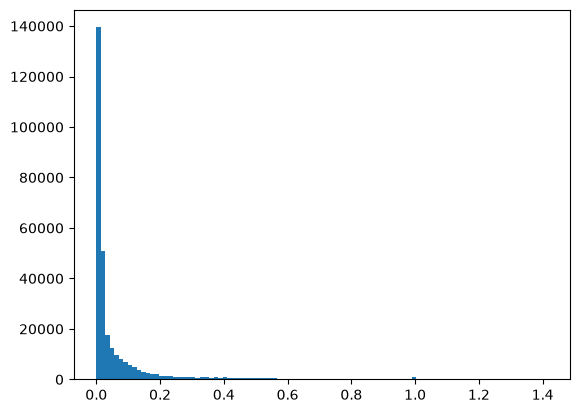

In [6]:
plt.hist(cam_gradmag.ravel(), bins=100)

(np.float64(-0.5), np.float64(539.5), np.float64(541.5), np.float64(-0.5))

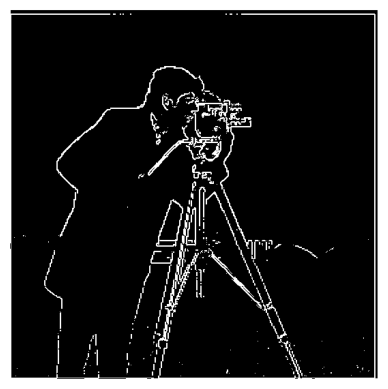

In [7]:
t=0.30
edges = cam_gradmag>t
plt.imshow(edges,cmap="gray");plt.axis("off")

(np.float64(-0.5), np.float64(539.5), np.float64(541.5), np.float64(-0.5))

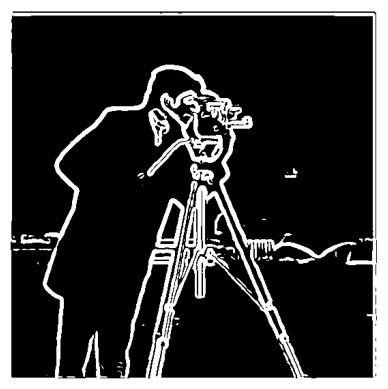

In [8]:
sigma = 2
ksize=int(6*sigma + 1)
g1d=cv2.getGaussianKernel(ksize,sigma)
G=g1d@g1d.T
blur=convolve2d(cameraman_img,G,mode="same")
dx=convolve2d(blur,Dx,mode="same")
dy=convolve2d(blur,Dy,mode="same")
gradmag=np.sqrt(dx**2+dy**2)

t=0.07
edges=gradmag>t
plt.imshow(edges,cmap="gray");plt.axis("off")

(np.float64(-0.5), np.float64(539.5), np.float64(541.5), np.float64(-0.5))

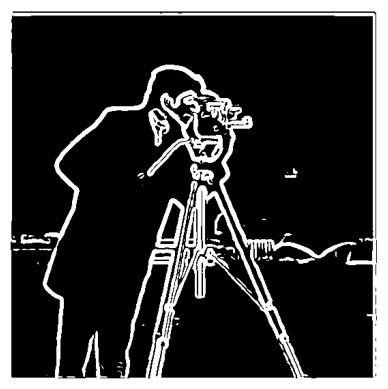

In [9]:
DGx = convolve2d(G, Dx, mode="full")
DGy = convolve2d(G, Dy, mode="full")
dx2=convolve2d(cameraman_img,DGx,mode="same")
dy2=convolve2d(cameraman_img,DGy,mode="same")
gradmag=np.sqrt(dx**2+dy**2)

t=0.07
edges=gradmag>t
plt.imshow(edges,cmap="gray");plt.axis("off")

In [10]:
sharp_weight = 2
ui = np.zeros_like(G)
ui[ksize//2, ksize//2] = 1
unsharp = (1 + sharp_weight) * ui - sharp_weight * G

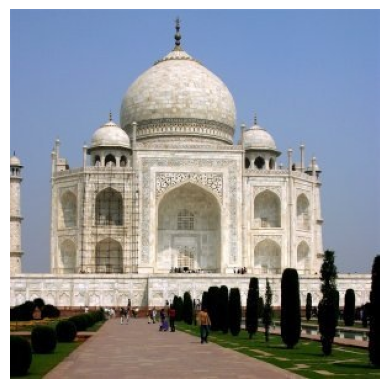

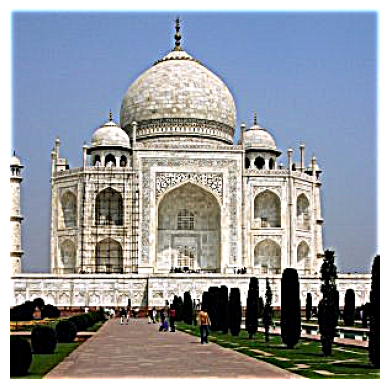

In [11]:
taj = skio.imread("media/taj.jpg") / 255
taj_sharp = np.dstack([convolve2d(taj[:,:,c], unsharp,mode="same") for c in range(3)])
taj_sharp = np.clip(taj_sharp, 0, 1)
plt.imshow(taj);plt.axis("off"); plt.show()
plt.imshow(taj_sharp);plt.axis("off"); plt.show()

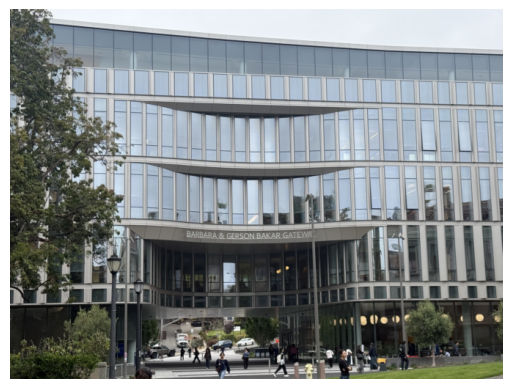

(504, 672, 3)


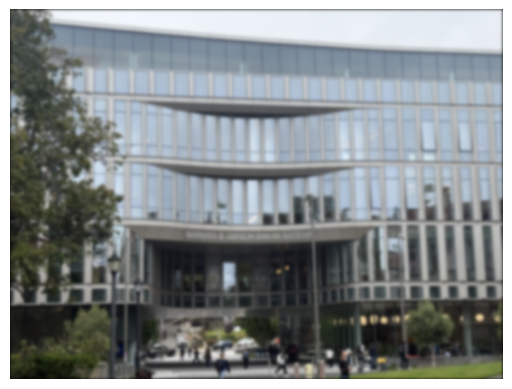

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8957131840681402..2.279211599301904].


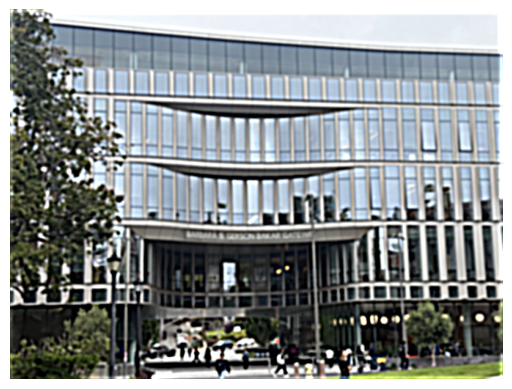

In [12]:
gateway = skio.imread("media/gateway_far.jpeg") / 255
h, w = gateway.shape[:2]
gateway = resize(gateway, (h // 6, w // 6), anti_aliasing=True)
plt.imshow(gateway);plt.axis("off"); plt.show()
print(gateway.shape)
gateway_blurred = np.dstack([convolve2d(gateway[:,:,c], G,mode="same") for c in range(3)])
plt.imshow(gateway_blurred);plt.axis("off"); plt.show()

sharp_weight = 8
ui = np.zeros_like(G)
ui[ksize//2, ksize//2] = 1
gateway_unsharp = (1 + sharp_weight) * ui - sharp_weight * G

gateway_sharpened = np.dstack([convolve2d(gateway_blurred[:,:,c], gateway_unsharp,mode="same") for c in range(3)])
plt.imshow(gateway_sharpened);plt.axis("off"); plt.show()




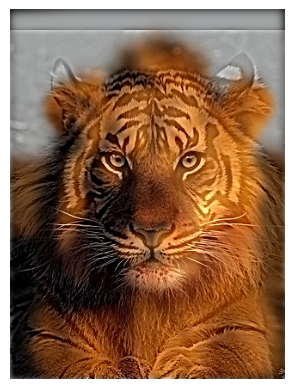

In [39]:
sigma1 = 5
sigma2 = 3

lion_rgb = np.load("lion_aligned.npy")
tiger_rgb = np.load("tiger_aligned.npy")


def gauss(sigma):
    k = int(6 * sigma + 1)
    g = cv2.getGaussianKernel(k, sigma)
    return g @ g.T

lion  = lion_rgb.mean(axis=2)  if lion_rgb.ndim == 3  else lion_rgb
tiger = tiger_rgb.mean(axis=2) if tiger_rgb.ndim == 3 else tiger_rgb

top, bottom, left, right = 80, 510, 0, 320
lion = lion[top:bottom, left:right]
tiger = tiger[top:bottom, left:right]
lion_rgb = lion_rgb[top:bottom, left:right]
tiger_rgb = tiger_rgb[top:bottom, left:right]

low_rgb = np.dstack([convolve2d(lion_rgb[..., c], gauss(sigma1), mode="same") for c in range(3)])

low  = convolve2d(lion,gauss(sigma1),  mode="same")
high = tiger-convolve2d(tiger, gauss(sigma2), mode="same")
hybrid = np.clip(low_rgb+high[..., None], 0, 1)
plt.imshow(hybrid, cmap="gray");plt.axis("off"); plt.show()


In [ ]:
def blur(im, sigma):
    kernel = gauss(sigma)
    if im.dim == 2:
        return convolve2d(im, kernel, mode="same",boundary="symm")
    return [convolve2d(im[:,:,c], kernel, mode="same",boundary="symm") for c in range(3)]

def gaussian_stack(im, levels=5, sigma=2):
    stack=[im]
    for i in range(1,levels):
        stack.append(blur(im, sigma*2**(i-1)))
    return stack

def plot_stack(stack, title="", laplacian=False):
    n = len(stack)
    fig, ax = plt.subplots(1, n, figsize=(3 * n, 3))
    for i, im in enumerate(stack):
        if laplacian and i < n - 1:
            im = (im - im.min()) / (im.max() - im.min())
        ax[i].imshow(np.clip(im, 0, 1), cmap="gray" if im.ndim == 2 else None)
        ax[i].set_title(f"{title} level {i}")
        ax[i].axis("off")
    plt.tight_layout(); plt.show()

G = gaussian_stack(apple, levels=5)
plot_stack(G, "Gaussian")